# **Combined model in d = 2** — Allen-Cahn $\oplus$ Model B $\oplus$ KPZ

The full multi-derivative-vertex theory at **two spatial dimensions**:

$$\partial_t\phi = -\mu\phi + D\,\nabla^2\phi
  \underbrace{-\,\lambda\phi^3}_{\text{Allen-Cahn}}
  \underbrace{+\,g\,\nabla^2(\phi^2)}_{\text{Model B}}
  \underbrace{+\,\tfrac{\kappa}{2}(\nabla\phi)^2}_{\text{KPZ}} + \eta,
  \qquad (\nabla\phi)^2 = (\partial_x\phi)^2 + (\partial_y\phi)^2,\quad d=2.$$

Three vertex types (plain `φ³`, composite `∇²(φ²)`, per-leg `(∇φ)²`) summed by the
**per-vertex form-factor table**, with the **d=2 transverse-moment loop average**.
Faster than the d=3 version; same question — does it run, and is it finite?

> **Heads-up:** like d=3, d=2 is UV-strong — the same-signature Model B × KPZ
> cross is UV-divergent — so the *bare* 1-loop is expected to be cutoff-set
> (this is v1, not a renormalisation package).  The point is that it computes.

In [1]:
import os, sys, time
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))     # nb_support engine
os.chdir(os.path.join(_root, 'notebooks'))
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import k0
import nb_support as nb
from models.spatial_field_2d_sim import simulate_2d, radial_correlator_2d

def order_label(ell):
    return ('tree' if ell == 0 else
            'tree + ' + ' + '.join('%d-loop' % j for j in range(1, ell + 1)))

# mass, diffusion, φ³ (Allen-Cahn), ∇²(φ²) (Model B), (∇φ)² (KPZ), noise temp
mu, D, lam, g, kpz, T = 1.0, 1.0, 0.1, 0.1, 0.2, 1.0

# The combined d=2 theory now lives in theories/combined_allencahn_modelb_kpz_2d.theory.py
# (φ³ Allen-Cahn ⊕ ∇²(φ²) Model B ⊕ (∇φ)² KPZ, spatial_dim=2, η stationary, infinite box).
model, _mod = nb.load_theory('combined_allencahn_modelb_kpz_2d')

## 0. Choose the order + parameters

In [2]:
# ============================  CHOOSE THE ORDER  ============================
MAX_ELL    = 1      # 0 = tree, 1 = +1-loop
K_EXTERNAL = 2
VERBOSE    = False
# ===========================================================================
xs = np.linspace(0.0, 5.0, 15)            # radial separations r ≥ 0
kw = dict(k=K_EXTERNAL, external_fields=[('phi', 1), ('phi', 1)], spatial_grid=xs,
          tau_max=0.0, tau_step=1.0, verbose=VERBOSE, use_cache=False, mf_dae_n_starts=4)
fund = {'mu': mu, 'D': D, 'lam': lam, 'g': g, 'kpz': kpz, 'T': T}
orders = list(range(0, MAX_ELL + 1))
# d=2 free continuum reference (r>0): C₀(r) = (T/2πD)·K₀(r√(μ/D))  (C₀(0) log-divergent)
kap = np.sqrt(mu / D)
C0_k0 = np.where(xs > 0, T / (2 * np.pi * D) * k0(kap * np.maximum(xs, 1e-9)), np.nan)

## 1. Theory — combined, multi-vertex, **d=2**

In [3]:
# Per-vertex form-factor table + d=2 transverse-moment loop average → this
# 3-vertex, mixed-mode theory computes.  (The same-sig Model B × KPZ cross is
# UV-divergent in d=2, so the bare 1-loop is cutoff-dependent.)
# Driven through the shared nb_support engine (theories/combined_…_2d.theory.py).
# NB: reload a FRESH model per order — compute_cumulants mutates the model dict
# in place, so reusing one object across ℓ corrupts the loop result (as in the
# original, which called build_combined() fresh each iteration).
curves, theory_ok = {}, True
try:
    for ell in orders:
        t0 = time.time()
        model_ell, mod_ell = nb.load_theory('combined_allencahn_modelb_kpz_2d')
        cfg = nb.Config(k=K_EXTERNAL, max_ell=ell,
                        external_fields=[('dphi', 1), ('dphi', 1)],
                        fundamental=fund, spatial_grid=xs,
                        tau_max=0.0, tau_step=1.0, verbose=VERBOSE)
        out = nb.run(model_ell, cfg, mod_ell)
        mid = out['C_tau_x'].shape[0] // 2
        curves[ell] = np.real(out['C_tau_x'])[mid]
        si = out.get('spatial_info', {}) or {}
        print('%-26s C(0,0) = %.4f   mode = %s   (%.0fs)'
              % (order_label(ell), curves[ell][0], si.get('vertex_mode', '—'), time.time() - t0))
    print('\n[combined d=2 RUNS: 3 vertex types, mixed modes, transverse-moment GH at d=2]')
except Exception as e:
    theory_ok = False
    import traceback
    print('THEORY raised: %s' % e); print(traceback.format_exc().splitlines()[-2])

tree                       C(0,0) = 0.5871   mode = —   (1s)


tree + 1-loop              C(0,0) = 0.5796   mode = None   (1s)

[combined d=2 RUNS: 3 vertex types, mixed modes, transverse-moment GH at d=2]


## 2. Simulation — the full 2-D SPDE

In [4]:
# Full combined 2-D SPDE: −λφ³, +g∇²(φ²), +(κ/2)(∇φ)².  (Model B's ∇² is stiff → dt=0.01.)
snaps, meta = simulate_2d(L=16.0, N=48, mu=mu, D=D, T=T,
                          lam=lam, g_lap=g, lam_kpz=kpz, dt=0.01,
                          n_steps=60000, burn_in=15000, record_every=20, seed=1)
ok = np.all(np.isfinite(snaps)) and np.max(np.abs(snaps)) < 30
if not ok:
    print('WARNING: 2-D sim blew up — reduce a coupling (g is the stiff one) or dt.')
mean = float(np.mean(snaps))                          # KPZ excess velocity ≠ 0
rc, Cr = radial_correlator_2d(snaps, meta, n_bins=24, r_max=5.0)
Cr_conn = Cr - mean ** 2                              # connected C(r)
print('combined 2-D SPDE ran:  ⟨φ⟩ (KPZ excess velocity) = %.4f' % mean)
print('   connected C(0,0) = ⟨φ²⟩−⟨φ⟩² = %.4f   max|φ| = %.2f' % (Cr_conn[0], float(np.max(np.abs(snaps)))))

combined 2-D SPDE ran:  ⟨φ⟩ (KPZ excess velocity) = 0.2583
   connected C(0,0) = ⟨φ²⟩−⟨φ⟩² = 0.4199   max|φ| = 3.69


## 3. Result

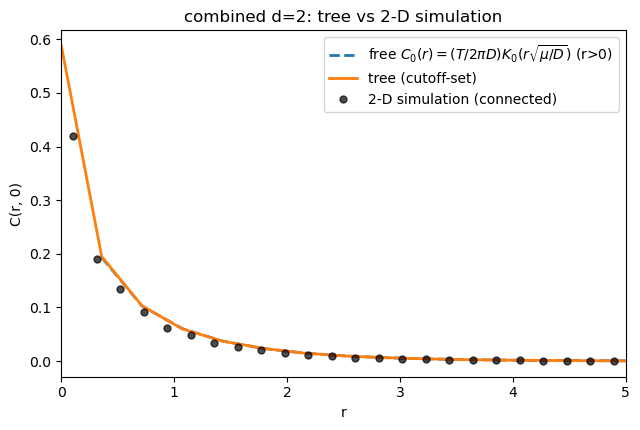

1-loop C(0,0) = 0.580

The point: the full 3-vertex, mixed-mode theory COMPUTES at d=2 (it ran).


In [5]:
# d=2 1-loop may be UV-divergent (same-sig cross) ⇒ plot tree vs sim; report 1-loop in text.
fig, ax = plt.subplots(figsize=(6.5, 4.4))
ax.plot(xs, C0_k0, '--', lw=2, color='C0', label=r'free $C_0(r)=(T/2\pi D)K_0(r\sqrt{\mu/D})$ (r>0)')
if theory_ok and 0 in curves:
    ax.plot(xs, curves[0], '-', lw=2, color='C1', label='tree (cutoff-set)')
ax.plot(rc, Cr_conn, 'o', ms=5, color='k', alpha=0.7, label='2-D simulation (connected)')
ax.set_xlabel('r'); ax.set_ylabel('C(r, 0)'); ax.set_xlim(0, xs.max())
ax.set_title('combined d=2: tree vs 2-D simulation'); ax.legend()
plt.tight_layout(); plt.show()

if theory_ok and (1 in curves):
    c1 = curves[1][0]
    finite_ish = abs(c1) < 5 * abs(curves[0][0])
    tag = '' if finite_ish else '  ← UV-DIVERGENT (same-sig Model B × KPZ cross; cutoff-set, off-scale)'
    print('1-loop C(0,0) = %.3f%s' % (c1, tag))
print('\nThe point: the full 3-vertex, mixed-mode theory COMPUTES at d=2 (it ran).')

## Summary

The full combined model **runs at d=2** — three vertex types (`φ³`, composite
`∇²(φ²)`, per-leg `(∇φ)²`), mixed `composite`/`perleg` modes via the per-vertex
form-factor table, loop integral the `L·d`-dim transverse-moment Gauss–Hermite.
The 2-D simulator integrates the same SPDE.

**d=2 caveat (physics, expected):** the same-signature Model B × KPZ cross is
UV-divergent in d=2 (as in d=3, just milder), so the *bare* 1-loop is
cutoff-set.  v1 is not a renormalisation package — the deliverable is that the
machinery composes and computes; the cutoff-robust observable is the KPZ excess
velocity (see the single-vertex `pipeline_kpz_2d_…` notebook).  See
`docs/spatial_d_ge_2.md`.